# Prithvi WxC Downscaling with CORDEX Data: Model Fine-tuning

This notebook demonstrates how to fine-tune the `Prithvi` downscaling model on CORDEX NZ data.

We show how to set up the model, load the pretrained weights, and run finetuning using the CORDEX-derived inputs.

The datasets are from https://zenodo.org/records/17517423

---

## Setup

Python >= 3.10 is required

Make sure that your current working directory is `granite-wxc/`

In [1]:
import os
import sys
from pathlib import Path
REPO_ROOT = Path("/mnt/data2/kyo/granite-wxc").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir("/mnt/data2/kyo/granite-wxc/examples/CORDEX_ML")
print(f"Working directory set to: {Path.cwd()}")

Working directory set to: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML


In [2]:
# ===================== CONFIGURATION / HARDWARE (EDIT ME) =====================
import os
import subprocess

enable_gpu_auto_select = True
min_free_mem_gb = 10.0
prefer_idle_gpus = True
max_gpus = 1
force_visible_devices = None  # e.g. "0,1"
seed = 123


def _parse_device_list(value):
    if value is None:
        return []
    return [int(part.strip()) for part in str(value).split(",") if part.strip()]


def _query_gpu_stats():
    query = "index,memory.total,memory.used,utilization.gpu"
    try:
        out = subprocess.check_output(
            ["nvidia-smi", f"--query-gpu={query}", "--format=csv,noheader,nounits"],
            text=True,
        )
    except Exception as exc:
        print(f"GPU status query failed (nvidia-smi unavailable): {exc}")
        return []

    stats = []
    for raw in out.strip().splitlines():
        if not raw.strip():
            continue
        idx_str, total_str, used_str, util_str = [part.strip() for part in raw.split(",")]
        util_digits = "".join(ch for ch in util_str if ch.isdigit())
        total_mb = int(total_str)
        used_mb = int(used_str)
        util = int(util_digits) if util_digits else 100
        stats.append(
            {
                "index": int(idx_str),
                "total_mb": total_mb,
                "used_mb": used_mb,
                "free_mb": max(total_mb - used_mb, 0),
                "util": util,
            }
        )
    return stats


def _select_gpu_indices(gpu_stats, threshold_mb, prefer_idle, max_devices):
    ranked = sorted(
        gpu_stats,
        key=(lambda g: (-g["free_mb"], g["util"], g["used_mb"], g["index"]))
        if prefer_idle
        else (lambda g: g["index"]),
    )
    selected = [g["index"] for g in ranked if g["free_mb"] >= threshold_mb]
    if max_devices is not None:
        selected = selected[: int(max_devices)]
    return selected


def configure_gpu_hardware():
    gpu_stats = _query_gpu_stats()
    available = [g["index"] for g in gpu_stats]
    threshold_mb = int(float(min_free_mem_gb) * 1024)
    selected = []
    reason = ""
    forced = force_visible_devices is not None and str(force_visible_devices).strip() != ""

    if forced:
        os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
        os.environ["CUDA_VISIBLE_DEVICES"] = str(force_visible_devices)
        selected = _parse_device_list(force_visible_devices)
        reason = "force_visible_devices override applied."
    elif enable_gpu_auto_select and gpu_stats:
        selected = _select_gpu_indices(gpu_stats, threshold_mb, prefer_idle_gpus, max_gpus)
        if not selected:
            selected = available[:]
            reason = (
                f"No GPU met min_free_mem_gb={min_free_mem_gb}. "
                "Falling back to all detected GPUs."
            )
        else:
            reason = "Auto-selected GPUs by free memory/utilization."
        os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
        os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(i) for i in selected)
    elif gpu_stats:
        selected = available[:] if max_gpus is None else available[: int(max_gpus)]
        os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
        os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(i) for i in selected)
        reason = "Auto-select disabled; using detected GPUs."
    else:
        reason = "No GPUs detected from nvidia-smi."

    if not gpu_stats:
        try:
            import torch  # fallback when nvidia-smi is unavailable

            count = torch.cuda.device_count()
        except Exception:
            count = 0
        if forced and selected:
            count = max(count, len(selected))
        if count > 0 and not forced:
            selected = list(range(count))
            os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
            os.environ["CUDA_VISIBLE_DEVICES"] = ",".join(str(i) for i in selected)
            reason = "nvidia-smi unavailable; using all torch-detected GPUs."
        elif count == 0 and not forced:
            selected = []

    if forced and selected and available:
        missing = [idx for idx in selected if idx not in available]
        if missing:
            print(f"Warning: forced GPU indices not detected by nvidia-smi: {missing}")

    selected_stats = {g["index"]: g for g in gpu_stats}
    use_gpu = len(selected) > 0
    world_size = len(selected) if use_gpu else 0
    strategy = "ddp" if world_size > 1 else ("single_gpu" if world_size == 1 else "cpu")

    print("Hardware summary:")
    print(f"  selected_original_gpus={selected}")
    print(f"  selected_visible_gpus={list(range(world_size)) if use_gpu else []}")
    if "CUDA_VISIBLE_DEVICES" in os.environ:
        print(f"  CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']}")
    if selected:
        for visible_idx, original_idx in enumerate(selected):
            stat = selected_stats.get(original_idx)
            if stat is None:
                print(f"  GPU orig={original_idx} vis={visible_idx}: stats unavailable")
                continue
            print(
                "  GPU orig={orig} vis={vis}: total={total:.1f}GB used={used:.1f}GB free={free:.1f}GB util={util}%".format(
                    orig=original_idx,
                    vis=visible_idx,
                    total=stat["total_mb"] / 1024.0,
                    used=stat["used_mb"] / 1024.0,
                    free=stat["free_mb"] / 1024.0,
                    util=stat["util"],
                )
            )
    else:
        print("  Warning: no usable GPUs selected; running on CPU.")
    print(f"  world_size={world_size}")
    print(f"  strategy={strategy}")
    if reason:
        print(f"  note={reason}")

    return {
        "selected_original_indices": selected,
        "world_size": world_size,
        "use_gpu": use_gpu,
        "strategy": strategy,
    }


GPU_SELECTION = configure_gpu_hardware()
SELECTED_GPU_ORIGINAL_IDS = GPU_SELECTION["selected_original_indices"]
SELECTED_GPU_COUNT = GPU_SELECTION["world_size"]
SELECTED_USE_GPU = GPU_SELECTION["use_gpu"]


Hardware summary:
  selected_original_gpus=[0]
  selected_visible_gpus=[0]
  CUDA_VISIBLE_DEVICES=0
  GPU orig=0 vis=0: total=22.5GB used=0.0GB free=22.5GB util=0%
  world_size=1
  strategy=single_gpu
  note=Auto-selected GPUs by free memory/utilization.


## GPU Selection Notes

- Set `force_visible_devices` (for example `"1"` or `"0,2"`) to bypass auto-selection and use those original GPU IDs.
- With auto-selection enabled, GPUs are ranked by highest free memory, then lowest utilization, then lowest used memory.
- `min_free_mem_gb` is the free-memory threshold. If no GPU meets it, the notebook falls back to all detected GPUs (or CPU if none are available).
- `max_gpus` caps how many selected GPUs are exposed through `CUDA_VISIBLE_DEVICES`.


In [3]:
# ===================== USER PARAMETERS (EDIT ME) =====================
from nz_params import UserParams, validate_paths


PROJECT_DIR = REPO_ROOT / "examples/CORDEX_ML"
DATASET_ROOT = REPO_ROOT / "granite-geospatial-wxc-downscaling/CORDEX/NZ_domain"

TRAIN_SPLIT = "train/ESD_pseudo_reality"
PREDICTOR_FILE = "ACCESS-CM2_1961-1980_regridded.nc"
TARGET_FILE = "pr_tasmax_ACCESS-CM2_1961-1980.nc"

TRAIN_PREDICTORS = [DATASET_ROOT / TRAIN_SPLIT / "predictors" / PREDICTOR_FILE]
TRAIN_TARGETS = [DATASET_ROOT / TRAIN_SPLIT / "target" / TARGET_FILE]

RUN_NAME_OVERRIDE = 'NZ_T1_ACCESS-CM2_static'  # e.g., 'nz_debug_run'
USE_STATIC = True  # set False to ignore static/orography inputs

P = UserParams(
    repo_root=REPO_ROOT,
    project_dir=PROJECT_DIR,
    runs_root=PROJECT_DIR / "runs/NZ_T1_ACCESS-CM2_static_train",
    config_path=PROJECT_DIR / "NZ_T1_ACCESS-CM2_static_v5.yaml",
    run_name=RUN_NAME_OVERRIDE,
    train_predictor_paths=TRAIN_PREDICTORS,
    train_target_paths=TRAIN_TARGETS,
    val_predictor_paths=TRAIN_PREDICTORS,
    val_target_paths=TRAIN_TARGETS,
    test_predictor_paths=TRAIN_PREDICTORS,
    test_target_paths=TRAIN_TARGETS,
    use_static=USE_STATIC,
    device_target="cuda" if SELECTED_USE_GPU else "cpu",
    batch_size=1,
    num_workers=2,
    preferred_checkpoint="best",
)

validate_paths(P)
print(P.summary())


Repo root: /mnt/data2/kyo/granite-wxc
Project dir: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML
Runs root: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs_v5/NZ_T1_ACCESS-CM2_static_train
Config: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/NZ_T1_ACCESS-CM2_static_v5.yaml
Run name override: NZ_T1_ACCESS-CM2_static
Inference run override: <latest>
Preferred checkpoint: best
Use static inputs: True
Device target: cuda
Batch size override: 1
Dataloader workers override: 2
Train predictors: 1 file(s)
Validation predictors: 1 file(s)
Test predictors: 1 file(s)
Checkpoint path override: <auto>


If your current directory is not `granite-wxc/`, change it using the following command:

```bash
%cd <local>/granite-wxc/
```

Replace `<local>` with the appropriate path prefix 

In [4]:
!pip install -q git+https://github.com/NASA-IMPACT/Prithvi-WxC.git

/bin/bash: /mnt/data2/kyo/.mamba/envs/Prithvi/bin/pip: /home/kyo/.mamba/envs/Prithvi/bin/python3.10: bad interpreter: No such file or directory


In [5]:
import os
import logging
import warnings

logging.disable(logging.CRITICAL)
warnings.simplefilter(action='ignore', category=FutureWarning)

os.chdir(P.project_dir)
print(f"Project directory set to: {os.getcwd()}")

Project directory set to: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML


In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.distributed import DistributedSampler

from cordex_dataset import CordexDownscaleDataset
from cordex_training import (
    get_dataloaders as build_cordex_dataloaders,
    create_finetune_model,
    run_training as launch_cordex_training,
)
from granitewxc.utils.config import get_config
from granitewxc.utils.distributed import init_ddp
from granitewxc.models.model import get_finetune_model_UNET, get_finetune_model
from granitewxc.utils.plot import plot_loss


Pysteps configuration file found at: /mnt/data2/kyo/.mamba/envs/Prithvi/lib/python3.10/site-packages/pysteps/pystepsrc



In [7]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

from cordex_dataset import CordexDownscaleDataset
from granitewxc.utils.config import get_config
from granitewxc.utils.distributed import init_ddp
from granitewxc.models.model import get_finetune_model_UNET, get_finetune_model
from granitewxc.utils.plot import plot_loss

Run setup utilities from `examples/CORDEX_ML/run_utils.py` are imported below and rely on the repository path specified in the parameter cell.

In [8]:
torch.jit.enable_onednn_fusion(True)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True
torch.manual_seed(seed)


It is possible to use a cpu or gpu/s to generate inferences. Based on avaiablity of a `cuda:gpu`, we set the device that the model uses

In [9]:
target = (getattr(P, 'device_target', 'auto') or 'auto').lower()
if target == 'cuda':
    if not torch.cuda.is_available():
        raise RuntimeError("device_target is 'cuda' but no CUDA device is available.")
    device = torch.device('cuda')
    use_gpu = True
elif target == 'cpu':
    device = torch.device('cpu')
    use_gpu = False
else:
    if torch.cuda.is_available():
        device = torch.device('cuda')
        use_gpu = True
    else:
        device = torch.device('cpu')
        use_gpu = False


In [10]:
print(device)

cuda


We initialize the Distributed Data Parallel (DDP) environment to leverage multiple GPUs for training

In [11]:
from pathlib import Path

config_path = P.config_path
config = get_config(str(config_path))
config.device_target = getattr(P, 'device_target', config.device_target)
if getattr(P, "use_static", None) is not None:
    config.data.use_static = bool(P.use_static)

def _override(attr: str, values):
    if values:
        setattr(config.data, attr, [str(Path(p).resolve()) for p in values])

_override('training_predictor_paths', P.train_predictor_paths)
_override('training_target_paths', P.train_target_paths)
_override('validation_predictor_paths', P.val_predictor_paths)
_override('validation_target_paths', P.val_target_paths)
_override('test_predictor_paths', P.test_predictor_paths)
_override('test_target_paths', P.test_target_paths)

if P.batch_size is not None:
    config.batch_size = int(P.batch_size)
if P.num_workers is not None:
    config.dl_num_workers = int(P.num_workers)

train_dl, val_dl = build_cordex_dataloaders(config, use_gpu)
len(train_dl), len(val_dl)


(7300, 7300)

## Configuration File

The model is configured using `YAML` files.

In these files, you specify:
- Paths to the input data  
- Locations of the pretrained weights  

To ensure compatibility with the provided weights during inference, keep the model configuration consistent with the original definitions 

In [12]:
import os

os.chdir(P.repo_root)
!pip install -e .
os.chdir(P.project_dir)

/bin/bash: /mnt/data2/kyo/.mamba/envs/Prithvi/bin/pip: /home/kyo/.mamba/envs/Prithvi/bin/python3.10: bad interpreter: No such file or directory


In [13]:
# Configuration already loaded using the USER PARAMETERS block.

In [14]:
# Working directory managed via the parameter cell.

In [15]:
from datetime import datetime
from pathlib import Path

from run_utils import (
    copy_scalars_to_run,
    prepare_run_paths,
    snapshot_resolved_config,
    update_manifest,
    write_manifest,
)
from nz_params import resolve_run_dir, export_params

RUN_NAME, resolved_run_dir = resolve_run_dir(P, config)
run_paths = prepare_run_paths(Path(P.runs_root), RUN_NAME)
assert run_paths.run_dir == resolved_run_dir

config.path_experiment = str(run_paths.run_dir)
config.checkpoint_dir = str(run_paths.checkpoints)
config.scalar_dir = str(run_paths.scalars)
config.preproc_dir = str(run_paths.preproc)

scalar_records = copy_scalars_to_run(config, run_paths.scalars)
resolved_config_path = snapshot_resolved_config(
    config, run_paths.config_dir / "resolved.yaml"
)
manifest = write_manifest(
    run_paths,
    run_name=RUN_NAME,
    base_config=str(config_path),
    resolved_config=resolved_config_path,
    scalars=scalar_records,
)

params_json = export_params(P, run_paths.run_dir / "params.json", extra={"run_name": RUN_NAME})
print(f"Run artifacts will be stored in {run_paths.run_dir}")
print(f"Config snapshot: {resolved_config_path}")
print(f"Saved parameter snapshot to {params_json}")

Run artifacts will be stored in /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs_v5/NZ_T1_ACCESS-CM2_static_train/NZ_T1_ACCESS-CM2_static
Config snapshot: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs_v5/NZ_T1_ACCESS-CM2_static_train/NZ_T1_ACCESS-CM2_static/config/resolved.yaml
Saved parameter snapshot to /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs_v5/NZ_T1_ACCESS-CM2_static_train/NZ_T1_ACCESS-CM2_static/params.json


## Dataloader 

In this CORDEX example we will use a single regridded data pair for both training and validation.

In [16]:
# This cell is deprecated; please use the helper functions defined earlier for dataloaders.


### Sample shapes

We check the batched tensor shapes from the CORDEX dataloader.

In [17]:
example_batch = next(iter(train_dl))
if "static_x" in example_batch:
    example_batch["x"].shape, example_batch["y"].shape, example_batch["static_x"].shape
else:
    example_batch["x"].shape, example_batch["y"].shape


In [18]:
target_shape = tuple(example_batch["y"].shape)
var_names = list(config.data.output_vars)
print(f"Configured output variables: {var_names}")
print(f"Sample target tensor shape: {target_shape}")
if target_shape[1] != len(var_names):
    raise ValueError(
        f"Dataloader returned {target_shape[1]} channels but config specifies {len(var_names)}"
    )
missing_expected = {"pr", "tasmax"} - set(var_names)
if missing_expected:
    raise ValueError(f"Missing expected NZ targets: {sorted(missing_expected)}")
print("Fine-tuning includes both 'pr' and 'tasmax'.")


Configured output variables: ['pr', 'tasmax']
Sample target tensor shape: (1, 2, 128, 128)
Fine-tuning includes both 'pr' and 'tasmax'.


## Model Initialization

We provide **2** different model architectures `UNET-like` and `CONV` 

Both architectures include:  
1. **Patch Embedding**: Extracts shallow features from the input data  
2. **Feature Extraction**: Utilizes the Prithvi backbone to extract deeper features  

The key difference is that the UNET-like version incorporates **static high-resolution data** into the model

In this notebook, we use the **UNET-like** version

To switch to the **CONV** model, update the configuration file accordingly and use `get_finetune_model(config)` 

In [19]:
model = create_finetune_model(config).to(device)


[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] resolved training output configuration:
  - pr: allow_negative_value=False, nonnegativity=(True, softplus), scaling=(divide_only, p95)
  - tasmax: allow_negative_value=False, nonnegativity=(False, none), scaling=(zscore, mean)
Creating the model.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> model has 254,372,744 params.
Loaded 200 tensors from /mnt/data2/kyo/granite-wxc/granite-geospatial-wxc-downscaling/ECCC/weights/best_rmse_UNET_small.pt. Skipped 8 mismatched entries.


We can now load the pretrained weights

In [20]:
# Pretrained weights are loaded via create_finetune_model().


## Finetuning

The model is now ready for training

In [21]:
from torch.optim import AdamW
from torch.cuda.amp import GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

from granitewxc.utils.trainer import train_model
try:
    from granitewxc.models.loss import rmse_loss
except ModuleNotFoundError:
    import torch

    def rmse_loss(y_hat, y):
        return torch.sqrt(torch.mean((y_hat - y['y']) ** 2))

## 
Defining the optimizer, scaler, and scheduler for the training process.

In [22]:
# Optimizer configuration handled inside cordex_training.run_training.


We'll train the model using just 1 data pair and run it for only 5 epochs

Let's train it for a couple of epochs based on the configuration file

In [23]:
try:
    train_losses, val_losses = launch_cordex_training(config, num_gpus=(1 if SELECTED_USE_GPU else 0), save_every=5)
except Exception as exc:
    print(f"Training failed: {exc}")
    raise


Single-GPU attempt on physical GPU 0.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] resolved training output configuration:
  - pr: allow_negative_value=False, nonnegativity=(True, softplus), scaling=(divide_only, p95)
  - tasmax: allow_negative_value=False, nonnegativity=(False, none), scaling=(zscore, mean)
Creating the model.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
[predictands] tasmax: allow_negative_value=False but nonnegativity.enabled=False. This is expected for temperature-like variables.
--> model has 254,372,744 params.
Loaded 200 tensors from /mnt/data2/kyo/granite-wxc/granite-geospatial-wxc-downscaling/ECCC/weights/best_rmse_UNET_small.pt. Skipped 8 mismatched entries.


/mnt/data2/kyo/.mamba/envs/Prithvi/lib/python3.10/site-packages/torch/distributed/fsdp/_init_utils.py:430: UserWarning: FSDP is switching to use `NO_SHARD` instead of ShardingStrategy.FULL_SHARD since the world size is 1.
  warnings.warn(
/mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/cordex_training.py:427: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_gpu and torch.cuda.is_available())
/mnt/data2/kyo/.mamba/envs/Prithvi/lib/python3.10/site-packages/torch/distributed/distributed_c10d.py:4876: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  warnings.warn(  # warn only once
[rank0]:[W305 05:24:31.128834562 ProcessGroupNCCL.cpp:5072] Guessing device ID based on global rank. This can cause a hang if rank to GPU mapping is heterogeneous. You can specify device_id in init_process_group()


Learning rate: 5e-05
Rank 0 starting epoch 1...


Training Epoch 1/10: 100%|██████████| 200/200 [06:08<00:00,  1.60s/batch, loss=10.2, lr=4.88e-5][W305 05:30:41.927194040 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
[W305 05:30:41.090456945 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
Training Epoch 1/10: 100%|██████████| 200/200 [06:09<00:00,  1.85s/batch, loss=10.2, lr=4.88e-5]


Validation Epoch: 100%|██████████| 50/50 [00:27<00:00,  2.32batch/s, loss=6.24][W305 05:31:09.361950362 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
[W305 05:31:09.476430470 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
Validation Epoch: 100%|██████████| 50/50 [00:27<00:00,  1.79batch/s, loss=6.24]
/mnt/data2/kyo/.mamba/envs/Prithvi/lib/python3.10/site-packages/torch/distributed/fsdp/_state_dict_utils.py:763: UserWarning: When using ``NO_SHARD`` for ``ShardingStrategy``, full_state_dict will be returned.
  warnings.warn(
/mnt/data2/kyo/.mamba/envs/Prithvi/lib/python3.10/site-packages/torch/distributed/fsdp/_state_dict_utils.py:701: UserWarning: When using ``NO_SHARD`` for ``ShardingStrategy``, full_state_dict will be returned.
  warnings.warn(


...

Learning rate: 2.1991153507687483e-06
Rank 0 starting epoch 10...


Training Epoch 10/10: 100%|██████████| 200/200 [05:26<00:00,  1.60s/batch, loss=6.65, lr=1e-6]   [W305 06:30:38.945678759 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
[W305 06:30:38.095289502 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
Training Epoch 10/10: 100%|██████████| 200/200 [05:27<00:00,  1.64s/batch, loss=6.65, lr=1e-6]


Validation Epoch: 100%|██████████| 50/50 [00:27<00:00,  2.32batch/s, loss=4.91] [W305 06:31:06.340775132 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
[W305 06:31:06.522509320 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
Validation Epoch: 100%|██████████| 50/50 [00:27<00:00,  1.79batch/s, loss=4.91]


--> saved /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs_v5/NZ_T1_ACCESS-CM2_static_train/NZ_T1_ACCESS-CM2_static/checkpoints/best.ckpt


[W305 06:31:58.803153416 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())


In [24]:
from pathlib import Path

checkpoint_info = {
    "best": str(Path(config.checkpoint_dir) / "best.ckpt"),
    "last": str(Path(config.checkpoint_dir) / "last.ckpt"),
}
manifest = update_manifest(run_paths.run_dir, checkpoints=checkpoint_info)
print("Updated run manifest with checkpoint locations:")
for label, ckpt_path in checkpoint_info.items():
    print(f"  {label}: {ckpt_path}")


Updated run manifest with checkpoint locations:
  best: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs_v5/NZ_T1_ACCESS-CM2_static_train/NZ_T1_ACCESS-CM2_static/checkpoints/best.ckpt
  last: /mnt/data2/kyo/granite-wxc/examples/CORDEX_ML/runs_v5/NZ_T1_ACCESS-CM2_static_train/NZ_T1_ACCESS-CM2_static/checkpoints/last.ckpt


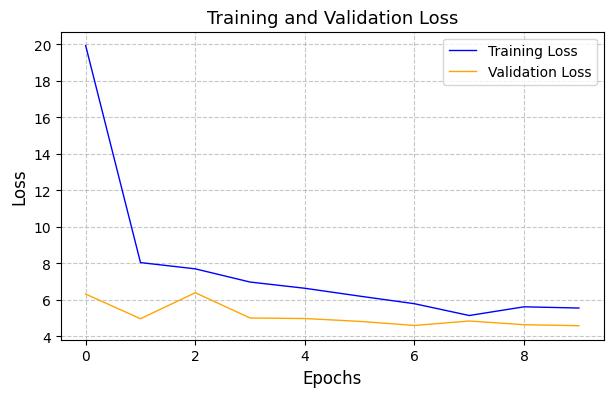

In [25]:
plot_loss(train_losses, val_losses)